# Path integration

Does the network track where it is? Decoded position vs. the true trajectory —
the paper's Fig. 1b,c (16cm after 15s trained, 91cm untrained).

Activations are **not** collected here: this notebook only needs positions, so it
skips the ~800MB of bottleneck/LSTM activity that `04_bottleneck_units.ipynb`
needs. Nothing is implemented here — measures come from `evaluate.py`, plots from
`figures.py`.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # so the usual relative paths (data/shards, results/) resolve

import numpy as np
import torch
import matplotlib.pyplot as plt

import evaluate
import figures
from config import Config
from dataset import build_dataloader

CHECKPOINT = "data/checkpoints/baseline/checkpoint_epoch299.pt"
N_TRAJECTORIES = 4000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = Config()
print(device, "|", ROOT)

cuda | /home/soluslan/workspace/grid-cells-torch


In [2]:
# Trained net, plus an untrained control run over the *same* trajectories.
model, untrained, epoch, place, hd = evaluate.load_models(cfg, CHECKPOINT, device)

loader = build_dataloader("data/shards", shard_indices=None,
                          batch_size=cfg.train.minibatch_size, shuffle=True)
batches, n_traj = evaluate.collect_batches(loader, N_TRAJECTORIES)
true_pos = np.concatenate([b["target_pos"].numpy() for b in batches], axis=0)

err, decoded, _, _ = evaluate.path_integration_errors(
    model, untrained, batches, place, hd, device, want_activations=False)

print(f"epoch {epoch} | {n_traj} trajectories x {true_pos.shape[1]} steps")

epoch 299 | 4000 trajectories x 100 steps


## Three decoders

The paper decodes self-location from the place cells but never says how, so all
three plausible readouts are measured. `floor` is the error left when the **true**
position's place-cell code is decoded — what a perfect path integrator would still
score, since a 256-cell code can only name cell centres. Without it there is no
way to say how much of the measured error is the network's.

In [3]:
evaluate.report_path_integration(err)
mode = evaluate.best_decoder(err)


=== path integration (100 steps x 0.15s = 15.0s trajectories) ===
  decoder       condition         t=0    final  mean over t
  argmax        trained         27.3c    17.7c        14.8c
  argmax        untrained      113.8c   112.0c       111.7c
  argmax        floor            6.9c     7.0c         7.0c
                -> network error above floor: 10.7cm,  effect size vs untrained = 2.51
  weighted_mean trained         65.5c    26.8c        25.8c
  weighted_mean untrained       84.6c    86.8c        86.1c
  weighted_mean floor            6.8c     6.9c         6.9c
                -> network error above floor: 19.9cm,  effect size vs untrained = 2.37
  top3          trained         23.0c    15.1c        11.9c
  top3          untrained       93.2c    88.8c        88.5c
  top3          floor            6.8c     6.9c         6.9c
                -> network error above floor: 8.3cm,  effect size vs untrained = 2.85
  (paper: 16cm trained, 91cm untrained after 15s, effect size 2.83)


In [4]:
# The curve shape, as numbers: settling transient first, then accumulating drift.
e = err["trained"][mode].mean(axis=0) * 100
floor = err["floor"][mode].mean() * 100
t_end = (len(e) - 1) * evaluate.STEP_SECONDS
t_min = e.argmin() * evaluate.STEP_SECONDS

print(f"decoder                {mode}")
print(f"t=0                    {e[0]:5.1f}cm   (LSTM settling out of its injected init)")
print(f"best  t={t_min:5.2f}s         {e.min():5.1f}cm   ({e.min() - floor:.1f}cm above the {floor:.1f}cm floor)")
print(f"final t={t_end:5.2f}s         {e[-1]:5.1f}cm   ({e[-1] - floor:.1f}cm above floor)")
print(f"drift after settling   {(e[-1] - e.min()) / (t_end - t_min):5.2f} cm/s")

decoder                top3
t=0                     23.0cm   (LSTM settling out of its injected init)
best  t= 1.95s           9.5cm   (2.6cm above the 6.9cm floor)
final t=14.85s          15.1cm   (8.3cm above floor)
drift after settling    0.44 cm/s


## Figure

Top: actual vs decoded trajectories (Fig. 1b). Bottom left: error accumulation —
the diagnostic a single end-of-trajectory number cannot give. Bottom right:
final-error distribution (Fig. 1c).

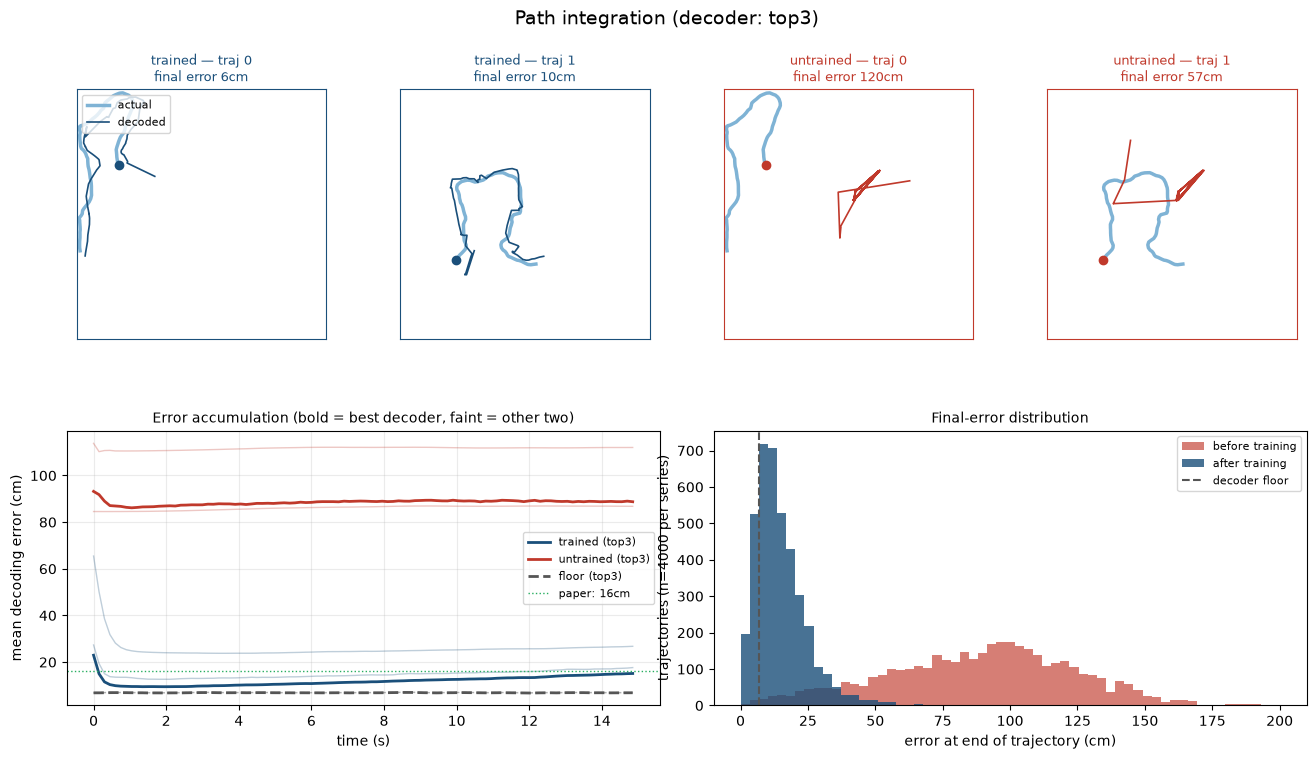

In [5]:
fig = figures.plot_path_integration(err, true_pos, decoded, mode, evaluate.DECODERS)
plt.show()

In [6]:
OUT_DIR = Path(evaluate.default_out_dir(CHECKPOINT))
OUT_DIR.mkdir(parents=True, exist_ok=True)
path = OUT_DIR / f"path_integration_epoch{epoch}.png"
fig.savefig(path, bbox_inches="tight", dpi=130)
print("saved", path)

saved /home/soluslan/workspace/grid-cells-torch/results/baseline/path_integration_epoch299.png
